In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
df1 = pd.read_csv("yellow_tripdata_2015-01.csv",low_memory=False)

# **Basic data exploration**

In [ ]:
df1.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1.0,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1.0,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2.0,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2.0,15.0,0.5,0.5,0.00,0.0,0.3,16.30


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33641 entries, 0 to 33640
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               33641 non-null  int64  
 1   tpep_pickup_datetime   33641 non-null  object 
 2   tpep_dropoff_datetime  33641 non-null  object 
 3   passenger_count        33641 non-null  int64  
 4   trip_distance          33641 non-null  float64
 5   pickup_longitude       33641 non-null  float64
 6   pickup_latitude        33641 non-null  float64
 7   RateCodeID             33641 non-null  int64  
 8   store_and_fwd_flag     33641 non-null  object 
 9   dropoff_longitude      33641 non-null  float64
 10  dropoff_latitude       33641 non-null  float64
 11  payment_type           33640 non-null  float64
 12  fare_amount            33640 non-null  float64
 13  extra                  33640 non-null  float64
 14  mta_tax                33640 non-null  float64
 15  ti

In [ ]:
df1.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
pickup_longitude,0
pickup_latitude,0
RateCodeID,0
store_and_fwd_flag,0
dropoff_longitude,0


In [ ]:
df1.describe()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,33641.000000,33641.000000,33641.000000,33641.000000,33641.000000,33641.000000,33641.000000,33641.000000,33640.000000,33640.000000,33640.000000,33640.000000,33640.000000,33640.000000,33640.000000,33640.000000
mean,1.523528,1.673761,2.763125,-72.635240,40.013394,1.032936,-72.692503,40.045875,1.382699,11.878134,0.332760,0.497666,1.547273,0.243232,0.285089,14.798452
std,0.499454,1.336341,3.357141,9.862770,5.433323,0.261905,9.653718,5.318233,0.495982,10.048159,0.378319,0.036602,2.242399,1.232582,0.065200,12.193401
min,1.000000,0.000000,0.000000,-74.302490,0.000000,1.000000,-74.393951,0.000000,1.000000,-52.000000,-1.000000,-0.500000,-14.330000,-5.330000,0.000000,-72.460000
25%,1.000000,1.000000,1.000000,-73.991600,40.735973,1.000000,-73.991051,40.734848,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.300000
50%,2.000000,1.000000,1.640000,-73.981384,40.753677,1.000000,-73.979858,40.753860,1.000000,9.000000,0.000000,0.500000,1.000000,0.000000,0.300000,11.200000
75%,2.000000,2.000000,3.000000,-73.966400,40.767670,1.000000,-73.962372,40.769012,2.000000,13.500000,0.500000,0.500000,2.100000,0.000000,0.300000,16.300000
max,2.000000,9.000000,56.800000,0.000000,41.016891,5.000000,0.000000,41.168850,4.000000,234.000000,1.500000,0.500000,100.000000,23.500000,0.300000,270.130000


# **Data cleaning**

In [ ]:
#changing integer values to time and tate format
df1["tpep_pickup_datetime"]=pd.to_datetime(df1['tpep_pickup_datetime'])
df1['tpep_dropoff_datetime']=pd.to_datetime(df1['tpep_dropoff_datetime'])

In [ ]:
# Invalid records with impossible fare, distance and passenger values were removed
df1 = df1[(df1['fare_amount'] > 0)]
df1 = df1[(df1['trip_distance'] > 0)]
df1 = df1[(df1['passenger_count'] > 0)]

# **Correlation Analysis**

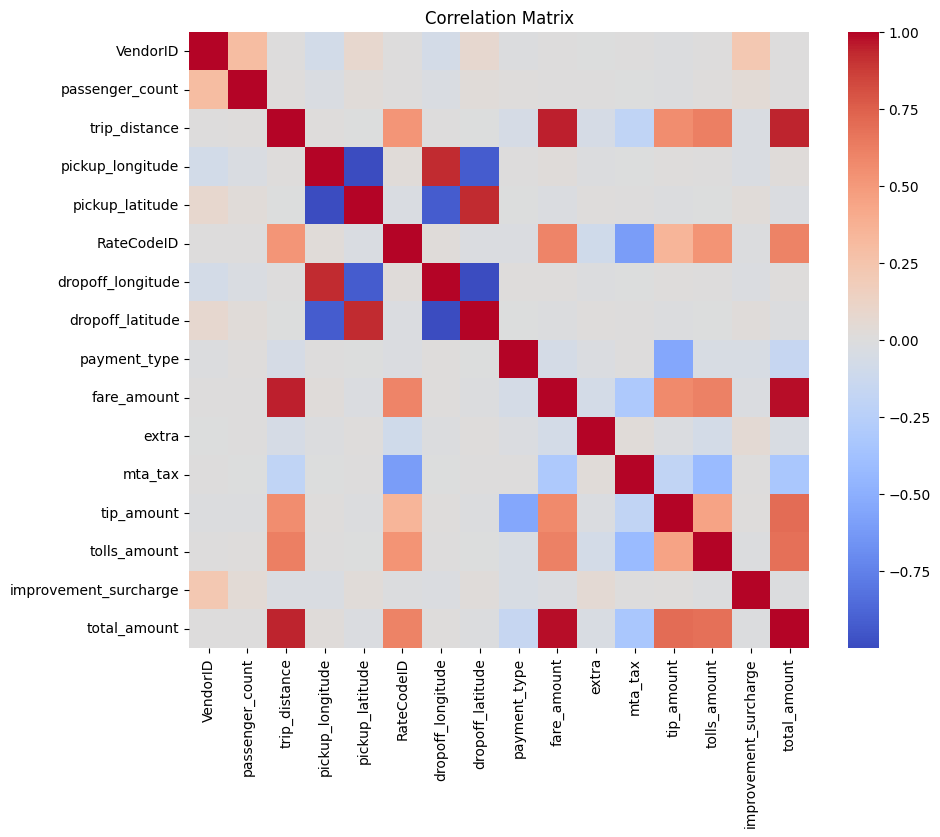

In [ ]:
corr = df1.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,cmap='coolwarm',annot=False)

plt.title("Correlation Matrix")
plt.show()

From this we can see trip distance shows the maximum corelation with fare amount and Rate Code ID

# **Pairplot**

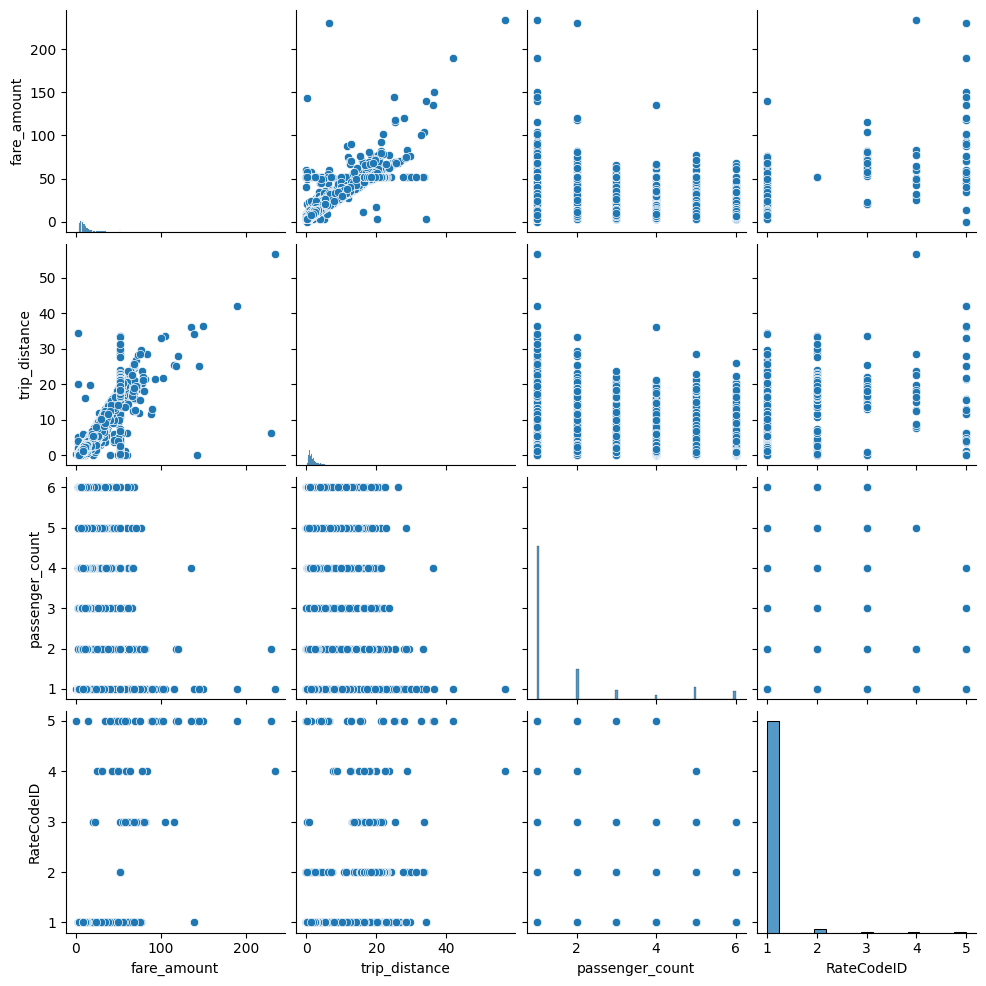

In [ ]:
sns.pairplot(df1[['fare_amount','trip_distance','passenger_count',"RateCodeID"]])

plt.show()

# **Feature Engineering and Selection**

In [ ]:

df1['trip_duration'] = (df1['tpep_dropoff_datetime']-df1['tpep_pickup_datetime']) / pd.Timedelta('1m')
df1['trip_duration']

,trip_duration
0,18.050000
1,19.833333
2,10.050000
3,1.866667
4,19.316667
...,...
33635,17.716667
33636,15.000000
33637,2.333333
33638,8.966667


In [ ]:
df1.loc[df1.RateCodeID>6 ,['RateCodeID']]
df1.loc[((df1.RateCodeID>6) | (df1.RateCodeID<1)),['RateCodeID']]=None
df1.RateCodeID.dropna(inplace=True)

In [ ]:
df1.loc[(df1.RateCodeID==1) & (df1.fare_amount>200),'fare_amount']=None
df1.fare_amount.dropna(inplace=True)

In [ ]:
x=df1.loc[:,['passenger_count','trip_distance','fare_amount','RateCodeID','trip_duration']]
x.corr(method='pearson')

,passenger_count,trip_distance,fare_amount,RateCodeID,trip_duration
passenger_count,1.000000,0.008559,0.007080,0.001240,0.000045
trip_distance,0.008559,1.000000,0.948433,0.516439,0.219235
fare_amount,0.007080,0.948433,1.000000,0.600730,0.238107
RateCodeID,0.001240,0.516439,0.600730,1.000000,0.107200
trip_duration,0.000045,0.219235,0.238107,0.107200,1.000000


# **Train Test Split**

In [ ]:
#adding rate code ID through one hot encoding for linear regression
df_OHE=pd.get_dummies(df1, columns=['RateCodeID'], drop_first=True)
X = df_OHE[['trip_distance', 'trip_duration',
                'RateCodeID_2.0', 'RateCodeID_3.0',
                'RateCodeID_4.0', 'RateCodeID_5.0']]
y = df_OHE['fare_amount']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(26728, 6)
(6683, 6)


Training and testing using 80-20 ratio

# **Linear Regression**

In [ ]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
# prediction with LR
pred_lr = lr.predict(X_test)

In [ ]:
rmse_lr = np.sqrt(mean_squared_error(y_test,pred_lr))

r2_lr = r2_score(y_test,pred_lr)

print("RMSE :",rmse_lr)
print("R² :",r2_lr)

RMSE : 3.1620214411534358
R² : 0.912633957129059


# **Random Forest**

In [ ]:
X2 = df1[['RateCodeID','trip_duration','trip_distance']]
Y2 = df1['fare_amount']

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, Y2, test_size=0.2, random_state=42)
rfr=RandomForestRegressor()
rfr.fit(X2_train,y2_train)

RandomForestRegressor()

In [ ]:
y_pred2=rfr.predict(X2_test)

In [ ]:
r2=rfr.score(X2_test,y2_test)
print('R sqaure % is',r2*100)

R sqaure % is 93.98508407519809


In [ ]:
rmse = np.sqrt(mean_squared_error(y2_test, y_pred2))
print('Root Mean Squared Error is:',rmse)


Root Mean Squared Error is: 2.6236642547089923


**We can conclude that Random forest regressor is better for predicting tax fares**